<a href="https://colab.research.google.com/github/Harsh374/Elevate-Labs-Task-6/blob/main/Elevate_Labs_Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 6: K-Nearest Neighbors (KNN) Classification**

*   Objective: Understand and implement KNN for classification problems.
*   Tools:  Scikit-learn, Pandas, Matplotlib
*   Dataset: Iris Dataset
*   What You'll Learn :Instance-based learning, Euclidean distance, K selection.



Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [2]:
file_path = "/content/Iris.csv"
iris_df = pd.read_csv(file_path)

Display basic info and first few rows

In [3]:
iris_df.info(), iris_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


(None,
    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
 0   1            5.1           3.5            1.4           0.2  Iris-setosa
 1   2            4.9           3.0            1.4           0.2  Iris-setosa
 2   3            4.7           3.2            1.3           0.2  Iris-setosa
 3   4            4.6           3.1            1.5           0.2  Iris-setosa
 4   5            5.0           3.6            1.4           0.2  Iris-setosa)

The Iris dataset is loaded successfully and contains the following columns:

*   Id: Identifier (can be dropped)
*   SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm: Feature columns
*   Species: Target variable (classification label)

Drop the 'Id' column

In [4]:
iris_df = iris_df.drop(columns=['Id'])

Encode the target labels

In [5]:
label_encoder = LabelEncoder()
iris_df['Species'] = label_encoder.fit_transform(iris_df['Species'])

Split features and labels

In [6]:
X = iris_df.drop('Species', axis=1)
y = iris_df['Species']

Normalize the feature columns

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

Train and evaluate KNN with different values of K

In [9]:
accuracies = []
k_values = range(1, 21)
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

Plot accuracy vs. K

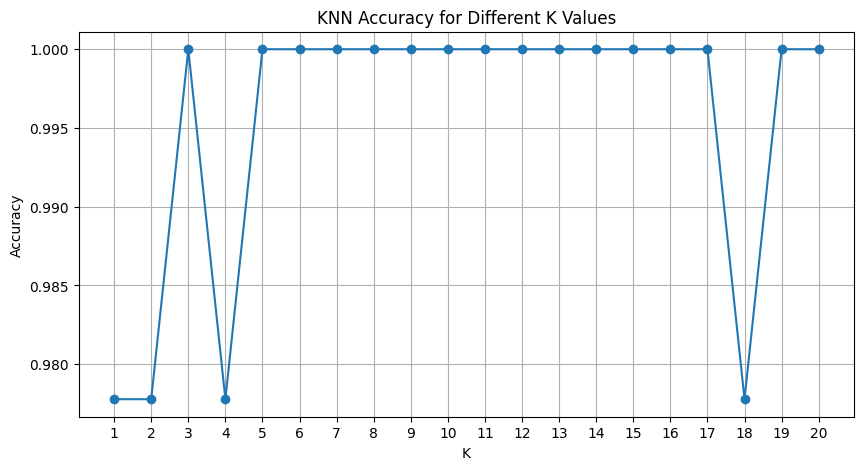

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, accuracies, marker='o')
plt.title("KNN Accuracy for Different K Values")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

Use best K (highest accuracy) for final model

In [11]:
best_k = k_values[np.argmax(accuracies)]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)

 Confusion matrix

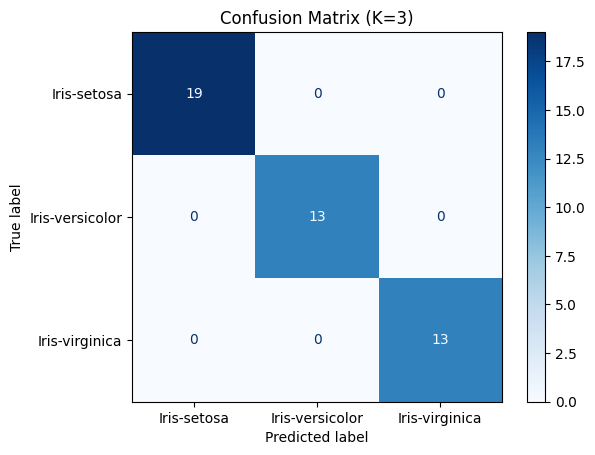

In [12]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (K={best_k})")
plt.show()

The code has successfully:
1. Preprocessed the Iris dataset (dropped Id, normalized features, encoded labels).
2. Trained KNN classifiers with k ranging from 1 to 20.
3. Plotted accuracy for each k value.
4. Evaluated the best model using a confusion matrix.

Visualize decision boundaries:

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

Use only the first two features for visualization

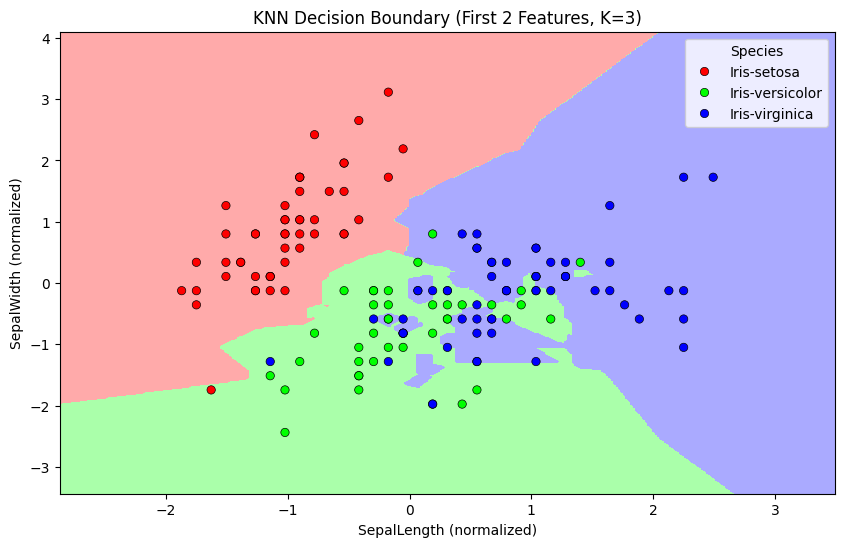

In [15]:
X_vis = X_scaled[:, :2]
X_train_vis, _, y_train_vis, _ = train_test_split(X_vis, y, test_size=0.3, random_state=42)

Train KNN using best_k and first two features

In [17]:
knn_vis = KNeighborsClassifier(n_neighbors=best_k)
knn_vis.fit(X_train_vis, y_train_vis)

KNeighborsClassifier(n_neighbors=3)

Create mesh grid

In [18]:
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Predict on mesh grid

In [19]:
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

 Plotting

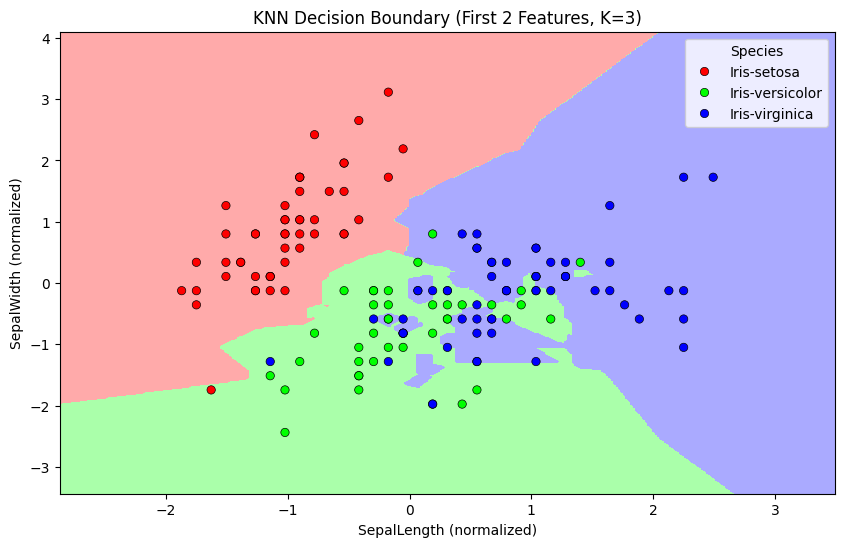

In [20]:
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
sns.scatterplot(x=X_vis[:, 0], y=X_vis[:, 1],
                hue=label_encoder.inverse_transform(y),
                palette=['#FF0000', '#00FF00', '#0000FF'],
                edgecolor='k')
plt.title(f"KNN Decision Boundary (First 2 Features, K={best_k})")
plt.xlabel("SepalLength (normalized)")
plt.ylabel("SepalWidth (normalized)")
plt.legend(title="Species")
plt.show()

 Visualizes KNN decision boundaries for all six unique feature pairs

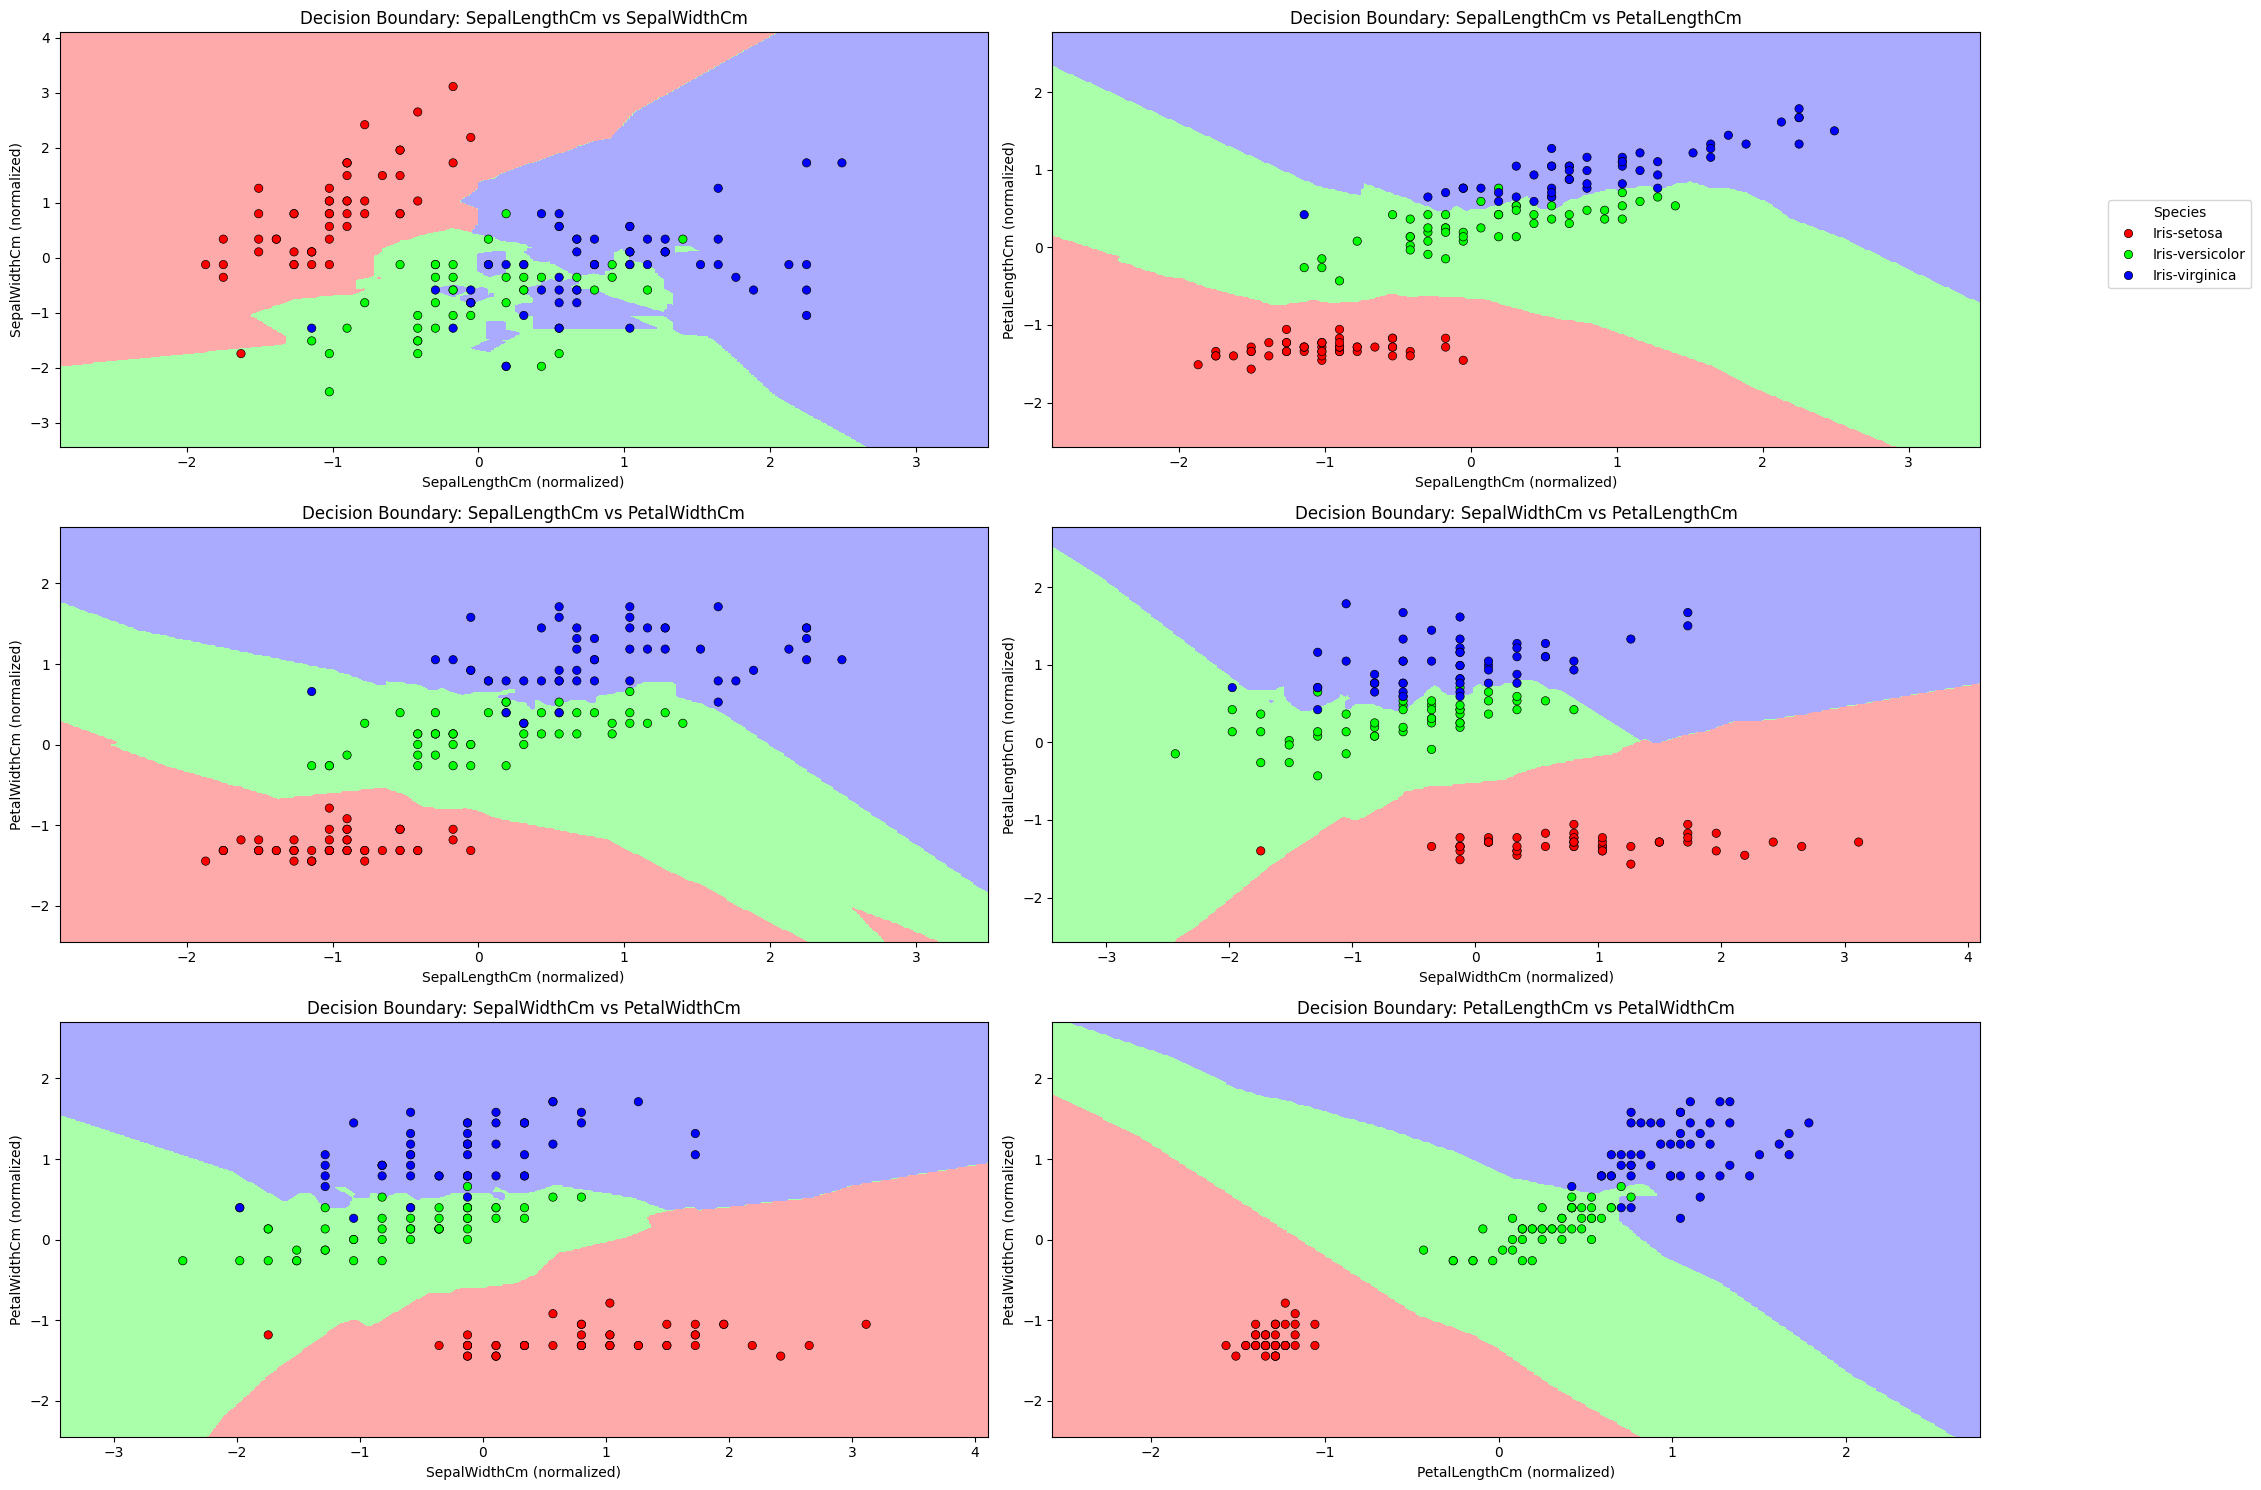

In [21]:
from itertools import combinations

# All combinations of the 4 features taken 2 at a time
feature_names = X.columns.tolist()
feature_indices = range(len(feature_names))
feature_pairs = list(combinations(feature_indices, 2))

# Plot settings
plt.figure(figsize=(20, 15))

for i, (idx1, idx2) in enumerate(feature_pairs, 1):
    # Use only two selected features
    X_pair = X_scaled[:, [idx1, idx2]]
    X_train_pair, _, y_train_pair, _ = train_test_split(X_pair, y, test_size=0.3, random_state=42)

    # Fit KNN
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_pair, y_train_pair)

    # Create mesh grid
    x_min, x_max = X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1
    y_min, y_max = X_pair[:, 1].min() - 1, X_pair[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict on mesh grid
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Subplot
    plt.subplot(3, 2, i)
    plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
    sns.scatterplot(x=X_pair[:, 0], y=X_pair[:, 1],
                    hue=label_encoder.inverse_transform(y),
                    palette=['#FF0000', '#00FF00', '#0000FF'], edgecolor='k')
    plt.xlabel(f"{feature_names[idx1]} (normalized)")
    plt.ylabel(f"{feature_names[idx2]} (normalized)")
    plt.title(f"Decision Boundary: {feature_names[idx1]} vs {feature_names[idx2]}")
    plt.legend().remove()

plt.tight_layout()
plt.legend(title="Species", loc='upper right', bbox_to_anchor=(1.3, 3))
plt.show()


What it does:
1. Iterates through each pair of features.
2. Trains a KNN classifier on each pair.
3. Plots decision boundaries in a 3x2 grid.